# <font color='purple'> Tarea 7
<font color='black'> 
Dayanni Godoy Rosales



### <font color='purple'> **1.- Función de Métricas de Desempeño.**

<font color='black'>

Genera una función en python que reciba un data frame con la evolución histórica de n cantidad de estrategías de inversión y calcule todas las métricas de desempeño vistas en las dos clases anteriores (Rendimiento, Volatilidad, Ratio de Sharpe, Downside, Upside, Omega, Beta, Alfa de Jensen, Ratio de Treynor, Ratio de Sortino).

In [406]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [ ]:
# Función de métricas de desempeño con variables renombradas
def calcular_metricas(df_historial, tasa_libre, capital_inicial):
    # Rendimientos diarios
    rets_diarios = df_historial.pct_change().dropna()
    
    # Rendimiento promedio anualizado de cada estrategia
    rendimiento_anual = rets_diarios.mean() * 252
    
    # Rendimiento anualizado del benchmark
    rendimiento_bench = rets_diarios["benchmark"].mean() * 252
    
    # Matriz de covarianza anualizada
    matriz_cov = rets_diarios.cov() * 252
    
    # DataFrame para guardar métricas
    df_metricas = pd.DataFrame(columns=df_historial.columns)
    
    # Rendimiento promedio
    df_metricas.loc["Rendimiento Promedio"] = rendimiento_anual
    
    # Rendimiento efectivo
    print(df_historial.iloc[-1])
    df_metricas.loc["Rendimiento Efectivo"] = df_historial.iloc[-1] / capital_inicial - 1
    
    # Volatilidad anualizada
    df_metricas.loc["Volatilidad"] = rets_diarios.std() * np.sqrt(252)
    
    # Sharpe
    df_metricas.loc["Sharpe"] = (df_metricas.loc["Rendimiento Promedio"] - tasa_libre) / df_metricas.loc["Volatilidad"]
    
    # Downside (solo pérdidas)
    rets_negativos = rets_diarios.copy()
    rets_negativos[rets_negativos > 0] = 0
    df_metricas.loc["Downside"] = rets_negativos.std() * np.sqrt(252)
    
    # Upside (solo ganancias)
    rets_positivos = rets_diarios.copy()
    rets_positivos[rets_positivos < 0] = 0
    df_metricas.loc["Upside"] = rets_positivos.std() * np.sqrt(252)
    
    # Omega
    df_metricas.loc["Omega"] = df_metricas.loc["Upside"] / df_metricas.loc["Downside"]
    
    # Beta
    df_metricas.loc["Beta"] = matriz_cov["benchmark"] / matriz_cov.loc["benchmark", "benchmark"]
    
    # Alfa de Jensen
    df_metricas.loc["Alpha Jensen"] = rendimiento_anual - (tasa_libre + df_metricas.loc["Beta"] * (rendimiento_bench - tasa_libre))
    
    # Treynor
    df_metricas.loc["Treynor"] = (rendimiento_anual - tasa_libre) / df_metricas.loc["Beta"]
    
    # Sortino
    df_metricas.loc["Sortino"] = (rendimiento_anual - tasa_libre) / df_metricas.loc["Downside"]
    
    return df_metricas


### <font color='purple'> **2.- Backtesting de Portafolio.**

<font color='black'>
Asume que quieres invertir en un portafolio compuesto por las siguientes acciones mexicanas: LIVEPOLC1.MX, KOFUBL.MX, CEMEXCPO.MX, CHDRAUIB.MX, CUERVO.MX, LABB.MX, RA.MX.
Debido a que no sabes como ponderarlos, decides realizar el backtesting para el portafolio para cuatro estrategias de Asset Allocation: Mínima Varianza, Máximo de Sharpe, Semivarianza Target y Omega.
Realiza el backtesting utilizando datos para simulación del 23-06-2024 hasta el 23-06-2025, toma un período anterior con el mismo horizonte temporal para optimizar las ponderaciones.
Recuerda siempre comparar con una estrategia de inversión pasiva, en este caso la opción lógica es el IPC México.
Gráfica la evolución histórica de las cinco alternativas de inversión.
Con los resultados del backtesting histórico calcula e interpreta las métricas de desempeño para las cinco alternativas de estrategias de inversión simuladas.

In [408]:
# Descarga de datos para opt y backtesting
tickers=['LIVEPOLC-1.MX','KOFUBL.MX', 'CEMEXCPO.MX', 'CHDRAUIB.MX', 'CUERVO.MX', 'LABB.MX', 'RA.MX']

#Opt
prices_opt = yf.download(tickers, start='2023-06-23', end='2024-06-23', progress=False)['Close']
rets_opt = prices_opt.pct_change().dropna()

#Backtesting
prices_bt = yf.download(tickers, start='2024-06-23', end='2025-06-23', progress=False)['Close']
rets_bt = prices_bt.pct_change().dropna()

#Benchmark
benchmark_opt=yf.download('^MXX', start='2023-06-23', end='2024-06-23', progress=False)['Close']
rets_benchmark_opt=benchmark_opt.pct_change().dropna()  .iloc[:, 0]

benchmark_bt=yf.download('^MXX', start='2024-06-23', end='2025-06-23', progress=False)['Close']
rets_benchmark_bt=benchmark_bt.pct_change().dropna()


In [409]:
# Selección de estrategias 

#  Optimización en Mínima Varianza
def opt_min_var(rets):
    cov=rets.cov()
    n_assets = len(rets.columns)
    var = lambda w: w.T @ cov @ w
    w0=np.ones(n_assets)/n_assets
    bounds=[(0, 1)]*n_assets
    constraint=lambda w: sum(w)-1
    result=minimize(fun=var, x0=w0, bounds=bounds, constraints={'fun': constraint, 'type': 'eq'}, tol=1e-16)
    return result.x

# Función para optimizar Sharpe
def opt_max_sharpe(rets, rf):
    E=rets.mean()
    cov=rets.cov()
    n_assets = len(rets.columns)
    rs = lambda w: -((w.T @ E - rf/252) / np.sqrt(w.T @ cov @ w))
    w0=np.ones(n_assets)/n_assets
    bounds=[(0, 1)]*n_assets
    constraint=lambda w: sum(w)-1
    result=minimize(fun=rs, x0=w0, bounds=bounds, constraints={'fun': constraint, 'type': 'eq'}, tol=1e-16)
    return result.x

# Función semivarianza target
def opt_target_semivar(rets, rets_benchmark):
    corr = rets.corr()
    diffs = rets - rets_benchmark.values.reshape(-1, 1) 
    bz = diffs[diffs < 0].fillna(0)
    target_downside = np.array(bz.std())
    target_semivar_matrix = target_downside.reshape(len(rets.columns),1) @ target_downside.reshape(1,len(rets.columns))*corr
    n_assets = len(rets.columns)
    semivar = lambda w: w.T @ target_semivar_matrix @ w
    w0 = np.ones(n_assets)/n_assets
    bounds = [(0.1,0.4)]*n_assets
    constraint = lambda w: sum(w)-1
    result = minimize(fun=semivar, x0=w0, bounds=bounds,
                      constraints={'fun': constraint, 'type': 'eq'}, tol=1e-16)
    return result.x

# Funcióm optimizar omega
def opt_max_omega(rets):
    n_assets = len(rets.columns)
    below_zero = rets[rets < 0].fillna(0)
    above_zero = rets[rets > 0].fillna(0)
    upside = np.array(above_zero.std())
    downside = np.array(below_zero.std())
    print(downside)
    # downside[downside == 0] = 1e-8
    omegas = upside/downside
    omega = lambda w: -np.sum(w*omegas)
    w0 = np.ones(n_assets)/n_assets
    bounds = [(0.1,0.4)]*n_assets
    constraint = lambda w: sum(w)-1
    result = minimize(fun=omega, x0=w0, bounds=bounds,
                      constraints={'fun': constraint, 'type': 'eq'}, tol=1e-16)
    return result.x

In [410]:
#obtener pesos óptimos (opt)
w_opt_min_var = opt_min_var(rets_opt)
w_opt_max_sharpe = opt_max_sharpe(rets_opt,rf = 0.0768)
w_opt_target_semivar = opt_target_semivar(rets_opt,rets_benchmark_opt)
w_opt_max_omega = opt_max_omega(rets_opt)

[0.01192423 0.00732155 0.01487963 0.00834053 0.01267039 0.00867427
 0.01220949]


In [411]:
# Diccionario con estrategias por probar
weights = {
    'Min var':w_opt_min_var, 
    "Max Sharpe": w_opt_max_sharpe, 
    "Target semivar":w_opt_target_semivar,
    "Omega":w_opt_max_omega,
    "benchmark": 1} #Se pone 1 porque asumimos que solo invertimos en 1, si quisieramos un benchmark combinado, cambiaría.
weights

{'Min var': array([0.04613323, 0.30909615, 0.11710919, 0.21646751, 0.00144483,
        0.24720929, 0.0625398 ]),
 'Max Sharpe': array([3.59060344e-17, 5.45505232e-01, 0.00000000e+00, 2.91818032e-18,
        9.34417906e-02, 3.61052977e-01, 0.00000000e+00]),
 'Target semivar': array([0.1       , 0.19908823, 0.1       , 0.18406811, 0.1       ,
        0.21684367, 0.1       ]),
 'Omega': array([0.1, 0.4, 0.1, 0.1, 0.1, 0.1, 0.1]),
 'benchmark': 1}

In [412]:
dict(zip(rets_opt.columns, w_opt_max_sharpe))

{'CEMEXCPO.MX': 3.590603441252254e-17,
 'CHDRAUIB.MX': 0.5455052322834975,
 'CUERVO.MX': 0.0,
 'KOFUBL.MX': 2.9181803249979827e-18,
 'LABB.MX': 0.09344179063966812,
 'LIVEPOLC-1.MX': 0.3610529770768344,
 'RA.MX': 0.0}

In [413]:
capital = 1_000_000
# Función Backtesting
def static_backtesting(prices: pd.DataFrame, benchmark: pd.DataFrame, weights: dict, capital: float):
    
    # Obtener rendimientos de precios y benchmark
    rets_assets = prices.pct_change().dropna()
    rets_benchmark = benchmark.pct_change().dropna().iloc[:, 0]  # asegurar serie 1D

    # DataFrame vacío para llenar historia
    history = pd.DataFrame(index=rets_assets.index)
    
    # Obtener evolución para cada estrategia dada
    for strategy in weights.keys():
        if strategy == "benchmark":
            history[strategy] = capital * (1 + rets_benchmark).cumprod()
        else:
            w = weights.get(strategy)
            returns_port = (rets_assets * w).sum(axis=1)
            returns_port = w @ rets_assets.T
            history[strategy] = capital * (1 + returns_port).cumprod()

    # Graficar la evolución
    plt.figure(figsize=(12,6))
    plt.plot(history)
    plt.legend(history.columns)
    plt.xlabel("Fechas")
    plt.ylabel("Valor del portafolio")
    plt.title("Evolución de Estrategias")
    plt.show()

    return history

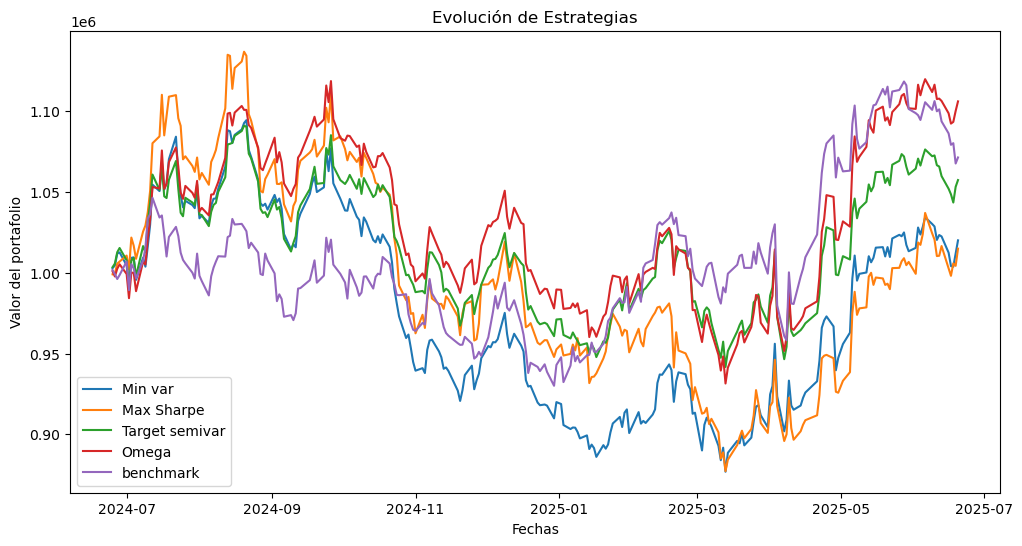

In [414]:
history = static_backtesting(
    prices=prices_bt,
    benchmark=benchmark_bt,
    weights=weights,
    capital=1_000_000
)

In [415]:
# Función de métricas de desempeño
def performance_metrics(history, rf,capital):
    # Rendimientos
    history_rets = history.pct_change().dropna()
    # Rendimiento promedio anualizado
    R_p = history_rets.mean() * 252
    # Rendimiento del benchmark
    R_m = history_rets["benchmark"].mean() * 252
    # Matriz de covarianza anualizada
    cov = history_rets.cov() * 252
    # DataFrame de métricas
    df = pd.DataFrame(columns=history.columns)
    # Rendimiento promedio
    df.loc["Rend Prom"] = R_p
    #Rendimiento efectivo
    print(history.iloc[-1])
    df.loc["Rend efectivo"] = history.iloc[-1]/capital-1
    # Volatilidad
    df.loc["Volatilidad"] = history_rets.std() * np.sqrt(252)
    # Sharpe
    df.loc["Sharpe"] = (df.loc["Rend Prom"] - rf) / df.loc["Volatilidad"]
    # Downside
    downside = history_rets.copy()
    downside[downside > 0] = 0
    df.loc["Downside"] = downside.std() * np.sqrt(252)
    # Upside
    upside = history_rets.copy()
    upside[upside < 0] = 0
    df.loc["Upside"] = upside.std() * np.sqrt(252)
    # Omega
    df.loc["Omega"] = df.loc["Upside"] / df.loc["Downside"]
    # Beta
    df.loc["Beta"] = cov["benchmark"] / cov.loc["benchmark", "benchmark"]
    # Alfa de Jensen
    df.loc["Alpha de Jensen"] = R_p - (rf + df.loc["Beta"] * (R_m - rf))
    # Treynor
    df.loc["Treynor"] = (R_p - rf) / df.loc["Beta"]
    # Sortino
    df.loc["Sortino"] = (R_p - rf) / df.loc["Downside"]
    return df

In [416]:
# Métricas de desempeño
performance_metrics(history, rf = 0.0768 ,capital=1_000_000)

Min var           1.020108e+06
Max Sharpe        1.014968e+06
Target semivar    1.057445e+06
Omega             1.106181e+06
benchmark         1.071445e+06
Name: 2025-06-20 00:00:00, dtype: float64


,Min var,Max Sharpe,Target semivar,Omega,benchmark
Rend Prom,0.030637,0.033172,0.065452,0.116880,0.080953
Rend efectivo,0.020108,0.014968,0.057445,0.106181,0.071445
Volatilidad,0.162980,0.184970,0.155148,0.172908,0.157158
Sharpe,-0.283243,-0.235865,-0.073144,0.231799,0.026426
Downside,0.095921,0.110462,0.094350,0.102175,0.092604
Upside,0.096667,0.109600,0.089454,0.104150,0.094444
Omega,1.007779,0.992193,0.948110,1.019324,1.019863
Beta,0.754423,0.745874,0.763071,0.813211,1.000000
Alpha de Jensen,-0.049296,-0.046726,-0.014517,0.036703,0.000000
Treynor,-0.061190,-0.058493,-0.014872,0.049286,0.004153


### <font color='purple'> **3.- Selección de Estrategia de Inversión.**

<font color='black'>
Utilizando los resultados de tu backtesting y las métricas de desempeño, selecciona una estrategia de inversión. Realiza una conclusión clara, breve y robusta de porque es la mejor estrategia PARA TI, apoyate en las métricas obtenidas y en tu perfil de aversión al riesgo.


In [417]:
dict(zip(rets_opt.columns, w_opt_max_omega))

{'CEMEXCPO.MX': 0.1,
 'CHDRAUIB.MX': 0.4,
 'CUERVO.MX': 0.10000000000000007,
 'KOFUBL.MX': 0.1,
 'LABB.MX': 0.1,
 'LIVEPOLC-1.MX': 0.1,
 'RA.MX': 0.1}

<font color='purple'>
La mejor estrategia en términos generales parece ser omega, sin embargo, al ver sus pesos, notamos que le da todo a Chedrahui, porque  tiene la mejor relación upside/downside por mucho, aunque la volatilidad de este portafolio es más alta, y no hay diversificación, pero el segundo lugar se lo lleva la estrategia pasiva (IPC), el tercer lugar se lo lleva semivar pero ya es una diferencia muy alta de rendimiento final. Así que, elegiremos OMEGA.

### <font color='purple'> **4.- Calculo de Pesos para Portafolio Real.** 

<font color='black'>
En base a la estrategia de Asset Allocation seleccionada en el punto anterior, calcula los pesos eficientes y la cantidad de acciones que utilizarías para invertir en la realidad en tu portafolio. Recuerda tomar la ventana de datos más reciente, en función del horizonte temporal tomado. 

In [418]:
# Obtener ponderaciones reales para implementar la estrategia
real= opt_max_omega(rets_bt)
dict(zip(rets_bt.columns, real*capital))

[0.01291319 0.00945789 0.01334749 0.00831614 0.01266343 0.00952179
 0.01316879]


{'CEMEXCPO.MX': 100000.00000000025,
 'CHDRAUIB.MX': 100000.00000000006,
 'CUERVO.MX': 100000.00000000022,
 'KOFUBL.MX': 399999.99999999994,
 'LABB.MX': 100000.0000000004,
 'LIVEPOLC-1.MX': 100000.0,
 'RA.MX': 100000.00000000816}

De nuevo le da todo a una sola acción.